# Evaluasi Model


In [28]:
# 1. Environment Setup & Imports
import os
import sys

BASE_DIR = '../..'
DATASET_PATH = os.path.join(BASE_DIR, 'ai_model', 'datasets', 'final_dataset.csv')
SAVE_DIR     = os.path.join(BASE_DIR, 'saved_models')
CKPT_DIR     = os.path.join(SAVE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import joblib
import time
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, AutoConfig

warnings.filterwarnings('ignore')
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(SEED)
print(f'Device: {DEVICE}')
print(f'Dataset path resolved: {DATASET_PATH}')
print(f'Model weights save directory: {SAVE_DIR}')


Device: cuda
Dataset path resolved: .\final_dataset.csv
Model weights save directory: .\saved_models


In [29]:
# 2. Text Preprocessing Function
def clean(text: str, lower: bool = True) -> str:
    if not isinstance(text, str): return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower() if lower else text


In [30]:
# 3. Load & Split Dataset
print('Loading dataset...')
df = pd.read_csv(DATASET_PATH)
print(f'Dataset loaded. Shape: {df.shape}')

y = df['fake_news_label'].values
idx = np.arange(len(df))

# Split: 70/15/15 stratified by Fake/Real
idx_train, idx_temp = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=SEED)

print(f'Split summary: Train={len(idx_train)} | Val={len(idx_val)} | Test={len(idx_test)}')


Loading dataset...
Dataset loaded. Shape: (26000, 6)
Split summary: Train=18200 | Val=3900 | Test=3900


## Define Architectures for Loading


In [31]:
# Attention pool and Bi-LSTM definition
class AttentionPool(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.w = nn.Linear(h*2, 1)
    def forward(self, x):
        weights = torch.softmax(self.w(x), dim=1)
        return (x * weights).sum(1)

class BiLSTMMTLClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            bidirectional=True, batch_first=True, dropout=dropout)
        self.pool = AttentionPool(hidden_dim)
        self.fake_real_head = nn.Linear(hidden_dim*2, 2)
        self.ai_human_head   = nn.Linear(hidden_dim*2, 2)
    def forward(self, x):
        emb_out = self.emb(x)
        lstm_out, _ = self.lstm(emb_out)
        pooled = self.pool(lstm_out)
        return self.fake_real_head(pooled), self.ai_human_head(pooled)

# Transformer definition
class TransformerMTLClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h_size = self.encoder.config.hidden_size
        self.fake_real_head = nn.Sequential(
            nn.Dropout(0.1), nn.Linear(h_size, h_size), nn.Tanh(),
            nn.Dropout(0.1), nn.Linear(h_size, 2)
        )
        self.ai_human_head = nn.Sequential(
            nn.Dropout(0.1), nn.Linear(h_size, h_size), nn.Tanh(),
            nn.Dropout(0.1), nn.Linear(h_size, 2)
        )
    def forward(self, **kwargs):
        if 'token_type_ids' in kwargs and self.encoder.config.model_type in ['roberta', 'distilroberta']:
            kwargs.pop('token_type_ids', None)
        out = self.encoder(**kwargs)
        cls_rep = out.last_hidden_state[:, 0, :]
        return self.fake_real_head(cls_rep), self.ai_human_head(cls_rep)


## Custom Datasets for Evaluation


In [32]:
def tokenize(text): return text.split()

def encode(text, vocab, max_len):
    ids = [vocab.get(w, 1) for w in tokenize(text)[:max_len]]
    return ids + [0] * (max_len - len(ids))

class BiLSTMMTLDataset(Dataset):
    def __init__(self, df_idx, vocab):
        df['bilstm_input'] = (df['title'].apply(lambda x: clean(x, lower=True)) + ' ' + 
                              df['text'].apply(lambda x: clean(x, lower=True)))
        self.X = [encode(df['bilstm_input'].iloc[i], vocab, 512) for i in df_idx]
        self.y_fake_real = [df['fake_news_label'].iloc[i] for i in df_idx]
        self.y_ai_human = [df['ai_label'].iloc[i] for i in df_idx]
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (
            torch.tensor(self.X[i], dtype=torch.long),
            torch.tensor(self.y_fake_real[i], dtype=torch.long),
            torch.tensor(self.y_ai_human[i], dtype=torch.long)
        )

class TransformerMTLDataset(Dataset):
    def __init__(self, df_idx, tokenizer, max_len=256):
        self.titles = [clean(df['title'].iloc[i], lower=False) for i in df_idx]
        self.texts  = [clean(df['text'].iloc[i], lower=False) for i in df_idx]
        self.y_fake_real  = [df['fake_news_label'].iloc[i] for i in df_idx]
        self.y_ai_human  = [df['ai_label'].iloc[i] for i in df_idx]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.titles)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.titles[idx], self.texts[idx], add_special_tokens=True,
                             max_length=self.max_len, padding='max_length', truncation=True,
                             return_attention_mask=True, return_tensors='pt')
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc, torch.tensor(self.y_fake_real[idx], dtype=torch.long), torch.tensor(self.y_ai_human[idx], dtype=torch.long)


## Prediction and Inference Latency Measuring Loop


In [33]:
results = {}

def evaluate_model(name, model, loader, is_transformer=False):
    model = model.float() # Force FP32 to prevent Half/Float mismatch
    model.eval()
    true_fake_real, pred_fake_real, probs_fake_real = [], [], []
    true_ai_human, pred_ai_human, probs_ai_human = [], [], []
    
    latencies = []
    
    with torch.no_grad():
        from tqdm.auto import tqdm
        for batch in tqdm(loader, desc=f'Evaluating {name}'):
            if is_transformer:
                enc, y_v, y_o = batch
                enc = {k: v.to(DEVICE) for k, v in enc.items()}
                y_v, y_o = y_v.to(DEVICE), y_o.to(DEVICE)
                
                t0 = time.perf_counter()
                # Use autocast to handle any remaining mixed precision operations
                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                    logits_fake_real, logits_ai_human = model(**enc)
                t1 = time.perf_counter()
            else:
                xb, y_v, y_o = batch
                xb, y_v, y_o = xb.to(DEVICE), y_v.to(DEVICE), y_o.to(DEVICE)
                
                t0 = time.perf_counter()
                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                    logits_fake_real, logits_ai_human = model(xb)
                t1 = time.perf_counter()
                
            latencies.append((t1 - t0) * 1000 / len(y_v))  # Latency per sample in ms
            
            true_fake_real.extend(y_v.cpu().numpy())
            pred_fake_real.extend(logits_fake_real.argmax(1).cpu().float().numpy())
            probs_fake_real.extend(torch.softmax(logits_fake_real.float(), dim=1)[:, 1].cpu().numpy())
            
            true_ai_human.extend(y_o.cpu().numpy())
            pred_ai_human.extend(logits_ai_human.argmax(1).cpu().float().numpy())
            probs_ai_human.extend(torch.softmax(logits_ai_human.float(), dim=1)[:, 1].cpu().numpy())
            
    avg_latency = np.mean(latencies)
    
    # Compute metrics
    metrics = {
        'ver_acc': accuracy_score(true_fake_real, pred_fake_real),
        'ver_prec': precision_score(true_fake_real, pred_fake_real, average='macro', zero_division=0),
        'ver_rec': recall_score(true_fake_real, pred_fake_real, average='macro', zero_division=0),
        'ver_f1': f1_score(true_fake_real, pred_fake_real, average='macro', zero_division=0),
        'ver_auc': roc_auc_score(true_fake_real, probs_fake_real),
        
        'ori_acc': accuracy_score(true_ai_human, pred_ai_human),
        'ori_prec': precision_score(true_ai_human, pred_ai_human, average='macro', zero_division=0),
        'ori_rec': recall_score(true_ai_human, pred_ai_human, average='macro', zero_division=0),
        'ori_f1': f1_score(true_ai_human, pred_ai_human, average='macro', zero_division=0),
        'ori_auc': roc_auc_score(true_ai_human, probs_ai_human),
        
        'latency_ms': avg_latency,
        
        'true_fake_real': true_fake_real, 'pred_fake_real': pred_fake_real, 'probs_fake_real': probs_fake_real,
        'true_ai_human': true_ai_human, 'pred_ai_human': pred_ai_human, 'probs_ai_human': probs_ai_human
    }
    results[name] = metrics
    print(f'[{name}] Fake/Real F1: {metrics["ver_f1"]:.4f} | AI/Human F1: {metrics["ori_f1"]:.4f} | Latency: {avg_latency:.2f} ms/article')



## Load Models & Run Evaluations


In [34]:
# 1. Evaluate Bi-LSTM
vocab_path = os.path.join(SAVE_DIR, 'bilstm_vocab.pkl')
if os.path.exists(vocab_path):
    vocab = joblib.load(vocab_path)
    
    bilstm = BiLSTMMTLClassifier(len(vocab), 300, 256).to(DEVICE)
    weights_path = os.path.join(SAVE_DIR, 'bilstm_best.pt')
    if os.path.exists(weights_path):
        sd = torch.load(weights_path, map_location=DEVICE)
        msd = {k.replace("veracity_head", "fake_real_head").replace("origin_head", "ai_human_head"): v for k, v in sd.items()}
        bilstm.load_state_dict(msd)
        
        # Evaluate on Train Set (Full 18200 samples)
        bilstm_ds_train = BiLSTMMTLDataset(idx_train, vocab)
        bilstm_dl_train = DataLoader(bilstm_ds_train, batch_size=128, shuffle=False)
        print(f"[*] Evaluating Bi-LSTM on Train Set ({len(idx_train)} samples)...")
        evaluate_model('Bi-LSTM (Train)', bilstm, bilstm_dl_train, is_transformer=False)
        
        # Evaluate on Validation Set
        bilstm_ds_val = BiLSTMMTLDataset(idx_val, vocab)
        bilstm_dl_val = DataLoader(bilstm_ds_val, batch_size=128, shuffle=False)
        print(f"[*] Evaluating Bi-LSTM on Validation Set ({len(idx_val)} samples)...")
        evaluate_model('Bi-LSTM (Val)', bilstm, bilstm_dl_val, is_transformer=False)
        
        # Evaluate on Test Set
        bilstm_ds_test = BiLSTMMTLDataset(idx_test, vocab)
        bilstm_dl_test = DataLoader(bilstm_ds_test, batch_size=128, shuffle=False)
        print(f"[*] Evaluating Bi-LSTM on Test Set ({len(idx_test)} samples)...")
        evaluate_model('Bi-LSTM (Test)', bilstm, bilstm_dl_test, is_transformer=False)
    else:
        print(f'Weights not found for Bi-LSTM at {weights_path}')
else:
    print('Vocab file not found. Skipping Bi-LSTM.')



[*] Evaluating Bi-LSTM on Train Set (18200 samples)...


Evaluating Bi-LSTM (Train):   0%|          | 0/143 [00:00<?, ?it/s]

[Bi-LSTM (Train)] Fake/Real F1: 0.9994 | AI/Human F1: 0.9995 | Latency: 0.80 ms/article
[*] Evaluating Bi-LSTM on Validation Set (3900 samples)...


Evaluating Bi-LSTM (Val):   0%|          | 0/31 [00:00<?, ?it/s]

[Bi-LSTM (Val)] Fake/Real F1: 0.9351 | AI/Human F1: 0.9812 | Latency: 0.84 ms/article
[*] Evaluating Bi-LSTM on Test Set (3900 samples)...


Evaluating Bi-LSTM (Test):   0%|          | 0/31 [00:00<?, ?it/s]

[Bi-LSTM (Test)] Fake/Real F1: 0.9400 | AI/Human F1: 0.9828 | Latency: 0.83 ms/article


In [35]:
# 2. Evaluate Transformers
for model_key, model_name in [('DistilRoBERTa', 'distilroberta'), ('RoBERTa', 'roberta'), ('DeBERTa-v3', 'deberta')]:
    weights_path = os.path.join(SAVE_DIR, f'{model_name}_best.pt')
    tok_path = os.path.join(SAVE_DIR, f'{model_name}_tokenizer')
    
    # Handle backbone configuration names
    backbone = 'distilroberta-base' if model_key == 'DistilRoBERTa' else (
        'roberta-base' if model_key == 'RoBERTa' else 'microsoft/deberta-v3-base'
    )
    
    if os.path.exists(weights_path):
        # Resolve tokenizer (from directory, zip file, or download fallback)
        if os.path.exists(tok_path) and os.path.isdir(tok_path):
            print(f'[*] Loading tokenizer for {model_key} from local path: {tok_path}')
            tokenizer = AutoTokenizer.from_pretrained(tok_path)
        else:
            # Try to find a zip file and extract it
            import glob, zipfile
            zip_pattern = os.path.join(SAVE_DIR, f'{model_name}_tokenizer*.zip')
            zip_files = glob.glob(zip_pattern)
            if zip_files:
                print(f'[*] Extracting tokenizer for {model_key} from {os.path.basename(zip_files[0])}...')
                try:
                    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
                        zip_ref.extractall(SAVE_DIR)
                    
                    # Search for where tokenizer was unzipped
                    unzipped_dir = tok_path
                    for root, dirs, files in os.walk(SAVE_DIR):
                        if "tokenizer_config.json" in files and f"{model_name}_tokenizer" in root:
                            unzipped_dir = root
                            break
                    tokenizer = AutoTokenizer.from_pretrained(unzipped_dir)
                except Exception as e:
                    print(f'[!] Failed to extract zip, using Hugging Face fallback for {model_key}: {e}')
                    tokenizer = AutoTokenizer.from_pretrained(backbone)
            else:
                print(f'[!] Tokenizer folder or zip not found. Downloading fallback tokenizer from Hugging Face for {model_key}...')
                tokenizer = AutoTokenizer.from_pretrained(backbone)
                
        model = TransformerMTLClassifier(backbone).to(DEVICE)
        sd = torch.load(weights_path, map_location=DEVICE)
        msd = {k.replace("veracity_head", "fake_real_head").replace("origin_head", "ai_human_head"): v for k, v in sd.items()}
        model.load_state_dict(msd)
        model.eval()
        
        # Evaluate on Train Set (Full 18200 samples)
        trans_ds_train = TransformerMTLDataset(idx_train, tokenizer, max_len=256 if model_key == 'DistilRoBERTa' else 512)
        trans_dl_train = DataLoader(trans_ds_train, batch_size=32, shuffle=False)
        print(f"[*] Evaluating {model_key} on Train Set ({len(idx_train)} samples)...")
        evaluate_model(f'{model_key} (Train)', model, trans_dl_train, is_transformer=True)
        
        # Evaluate on Validation Set
        trans_ds_val = TransformerMTLDataset(idx_val, tokenizer, max_len=256 if model_key == 'DistilRoBERTa' else 512)
        trans_dl_val = DataLoader(trans_ds_val, batch_size=32, shuffle=False)
        print(f"[*] Evaluating {model_key} on Validation Set ({len(idx_val)} samples)...")
        evaluate_model(f'{model_key} (Val)', model, trans_dl_val, is_transformer=True)
        
        # Evaluate on Test Set
        trans_ds_test = TransformerMTLDataset(idx_test, tokenizer, max_len=256 if model_key == 'DistilRoBERTa' else 512)
        trans_dl_test = DataLoader(trans_ds_test, batch_size=32, shuffle=False)
        print(f"[*] Evaluating {model_key} on Test Set ({len(idx_test)} samples)...")
        evaluate_model(f'{model_key} (Test)', model, trans_dl_test, is_transformer=True)
    else:
        print(f'[!] Weights file not found for {model_key} ({model_name}_best.pt). Skipping.')



[*] Loading tokenizer for DistilRoBERTa from local path: .\saved_models\distilroberta_tokenizer


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Evaluating DistilRoBERTa on Train Set (18200 samples)...


Evaluating DistilRoBERTa (Train):   0%|          | 0/569 [00:00<?, ?it/s]

...

[DeBERTa-v3 (Train)] Fake/Real F1: 0.9966 | AI/Human F1: 0.9959 | Latency: 1.93 ms/article
[*] Evaluating DeBERTa-v3 on Validation Set (3900 samples)...


Evaluating DeBERTa-v3 (Val):   0%|          | 0/122 [00:00<?, ?it/s]

[DeBERTa-v3 (Val)] Fake/Real F1: 0.9800 | AI/Human F1: 0.9909 | Latency: 1.89 ms/article
[*] Evaluating DeBERTa-v3 on Test Set (3900 samples)...


Evaluating DeBERTa-v3 (Test):   0%|          | 0/122 [00:00<?, ?it/s]

[DeBERTa-v3 (Test)] Fake/Real F1: 0.9836 | AI/Human F1: 0.9912 | Latency: 1.84 ms/article


## Comparison Metrics Table


In [51]:
# 3. Tables - Combined Evaluation & Final Comparison
import pandas as pd
import os
from IPython.display import display

base_models = ['Bi-LSTM', 'DistilRoBERTa', 'RoBERTa', 'DeBERTa-v3']
splits = ['Train', 'Val', 'Test']

# Fungsi bantuan untuk memformat angka menjadi desimal 4 digit
def fmt(val):
    return f"{val:.4f}"

print("=== 1. EVALUASI OVERFITTING (SEMUA MODEL DALAM 1 TABEL) ===")
all_rows = []
for base in base_models:
    for split in splits:
        name = f"{base} ({split})"
        if name in results:
            m = results[name]
            all_rows.append({
                'Model': base,
                'Split': split,
                '[FR] Acc': fmt(m['ver_acc']),
                '[FR] Prec': fmt(m['ver_prec']),
                '[FR] Rec': fmt(m['ver_rec']),
                '[FR] F1': fmt(m['ver_f1']),
                '[AI] Acc': fmt(m['ori_acc']),
                '[AI] Prec': fmt(m['ori_prec']),
                '[AI] Rec': fmt(m['ori_rec']),
                '[AI] F1': fmt(m['ori_f1']),
                'Joint F1': fmt((m['ver_f1'] + m['ori_f1']) / 2)
            })

if all_rows:
    # Set Multi-Index agar Model dan Split tergabung rapi di kolom kiri
    df_combined = pd.DataFrame(all_rows).set_index(['Model', 'Split'])
    
    # CSS Styling untuk mewarnai tabel Overfitting
    styles_combined = [
        {'selector': 'th', 'props': [('background-color', "#0D6FD6"), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px')]}
    ]
    styled_combined = df_combined.style.set_table_styles(styles_combined).set_properties(**{'border': '1px solid black', 'background-color': '#fcfcfc','color': 'black'})
    
    display(styled_combined)
    # Simpan juga ke CSV barangkali mau dimasukkan Excel
    df_combined.to_csv(os.path.join(SAVE_DIR, 'overfitting_evaluation_all.csv'))

print("\n\n=== 2. FINAL MODEL COMPARISON (TEST SET ONLY) ===")
test_rows = []
for base in base_models:
    name = f"{base} (Test)"
    if name in results:
        m = results[name]
        test_rows.append({
            'Model': base,
            'FR Acc': fmt(m['ver_acc']),
            'FR Prec': fmt(m['ver_prec']),
            'FR Rec': fmt(m['ver_rec']),
            'FR F1': fmt(m['ver_f1']),
            'FR AUC': fmt(m['ver_auc']),
            'AI Acc': fmt(m['ori_acc']),
            'AI Prec': fmt(m['ori_prec']),
            'AI Rec': fmt(m['ori_rec']),
            'AI F1': fmt(m['ori_f1']),
            'AI AUC': fmt(m['ori_auc']),
            'Joint F1': fmt((m['ver_f1'] + m['ori_f1']) / 2),
            'Latency (ms)': f"{m['latency_ms']:.2f}"
        })

if test_rows:
    df_test = pd.DataFrame(test_rows).set_index('Model').T
    
    # CSS Styling untuk mewarnai tabel Final Test (Warna Hijau)
    styles_test = [
        {'selector': 'th', 'props': [('background-color', '#4a7c59'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px')]}
    ]
    styled_test = df_test.style.set_table_styles(styles_test).set_properties(**{'border': '1px solid black', 'background-color': '#fcfcfc','color': 'black'})
    
    display(styled_test)
    df_test.to_csv(os.path.join(SAVE_DIR, 'final_test_comparison.csv'))

=== 1. EVALUASI OVERFITTING (SEMUA MODEL DALAM 1 TABEL) ===




=== 2. FINAL MODEL COMPARISON (TEST SET ONLY) ===


Model,Bi-LSTM,DistilRoBERTa,RoBERTa,DeBERTa-v3
FR Acc,0.9400,0.9797,0.9882,0.9836
FR Prec,0.9400,0.9797,0.9882,0.9836
FR Rec,0.9400,0.9797,0.9882,0.9836
FR F1,0.9400,0.9797,0.9882,0.9836
FR AUC,0.9852,0.9980,0.9989,0.9980
AI Acc,0.9877,0.9933,0.9962,0.9936
AI Prec,0.9862,0.9908,0.9938,0.9885
AI Rec,0.9795,0.9908,0.9956,0.9939
AI F1,0.9828,0.9908,0.9947,0.9912
AI AUC,0.9975,0.9985,0.9994,0.9989


## Visualization - Confusion Matrices


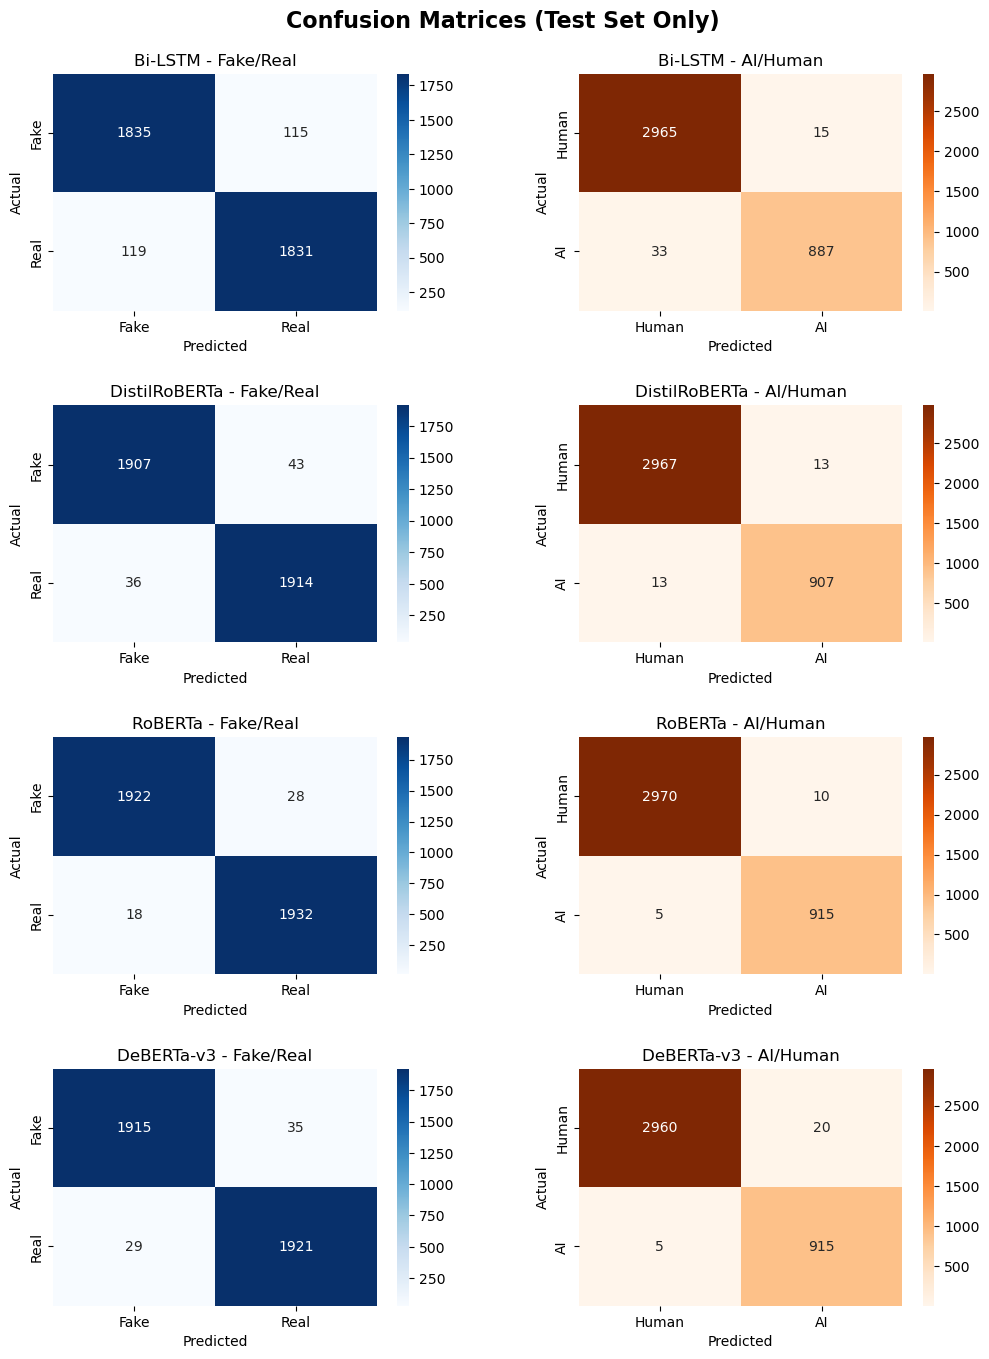

In [46]:
# 4. Visualization - Confusion Matrices (Test Set Only)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(len(test_rows), 2, figsize=(12, 4 * len(test_rows)))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for idx, row in enumerate(test_rows):
    base = row['Model']
    m = results[f"{base} (Test)"]
    
    # Fake/Real
    cm_v = confusion_matrix(m['true_fake_real'], m['pred_fake_real'])
    sns.heatmap(cm_v, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    axes[idx, 0].set_title(f'{base} - Fake/Real')
    axes[idx, 0].set_xlabel('Predicted'); axes[idx, 0].set_ylabel('Actual')
    
    # AI/Human
    cm_o = confusion_matrix(m['true_ai_human'], m['pred_ai_human'])
    sns.heatmap(cm_o, annot=True, fmt='d', cmap='Oranges', ax=axes[idx, 1],
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    axes[idx, 1].set_title(f'{base} - AI/Human')
    axes[idx, 1].set_xlabel('Predicted'); axes[idx, 1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set Only)', fontsize=16, fontweight='bold', y=0.92)
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices_test.png'), bbox_inches='tight')
plt.show()



## Visualization - ROC Curves


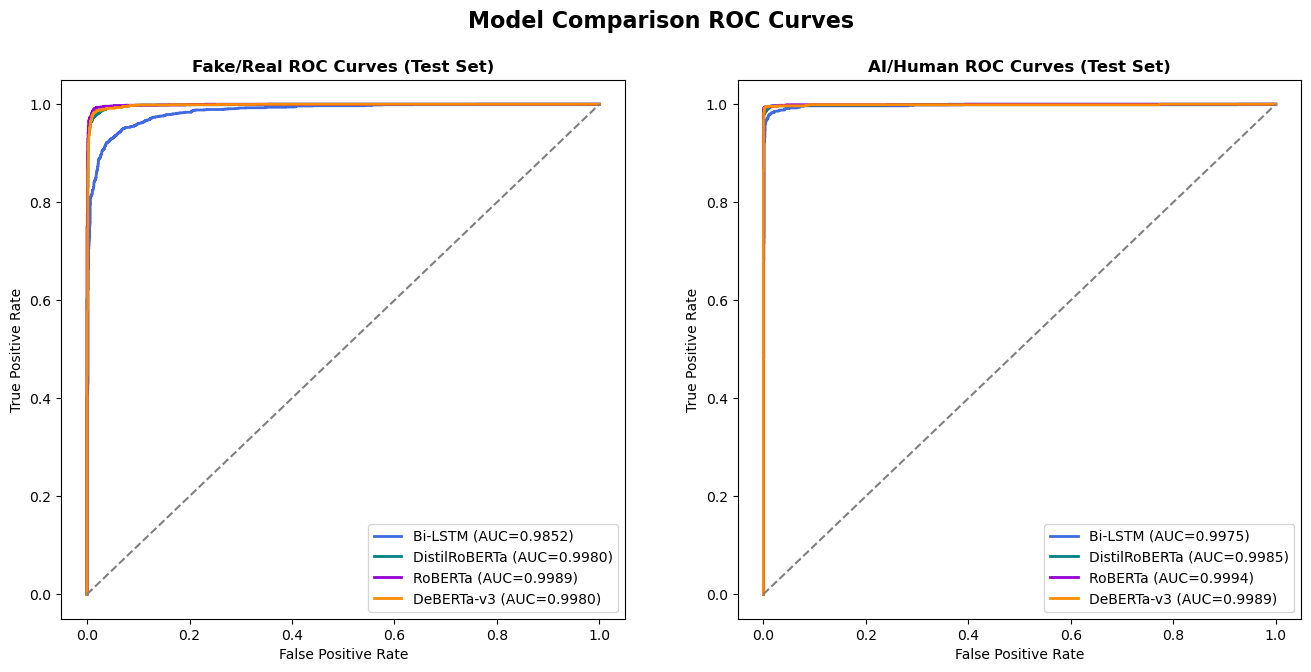

In [47]:
# 5. Visualization - ROC Curves Comparison (Test Set Only)
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = {'Bi-LSTM': 'royalblue', 'DistilRoBERTa': 'teal', 'RoBERTa': 'darkviolet', 'DeBERTa-v3': 'darkorange'}

for row in test_rows:
    base = row['Model']
    m = results[f"{base} (Test)"]
    color = colors.get(base, 'black')
    
    # Fake/Real ROC
    fpr_v, tpr_v, _ = roc_curve(m['true_fake_real'], m['probs_fake_real'])
    ax1.plot(fpr_v, tpr_v, color=color, linewidth=2, label=f'{base} (AUC={m["ver_auc"]:.4f})')
    
    # AI/Human ROC
    fpr_o, tpr_o, _ = roc_curve(m['true_ai_human'], m['probs_ai_human'])
    ax2.plot(fpr_o, tpr_o, color=color, linewidth=2, label=f'{base} (AUC={m["ori_auc"]:.4f})')

ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_title('Fake/Real ROC Curves (Test Set)', fontweight='bold')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_title('AI/Human ROC Curves (Test Set)', fontweight='bold')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right')

plt.suptitle('Model Comparison ROC Curves', fontsize=16, fontweight='bold', y=0.98)
plt.savefig(os.path.join(SAVE_DIR, 'roc_curves_test.png'), bbox_inches='tight')
plt.show()



## Visualization - Inference Latency (ms per article)


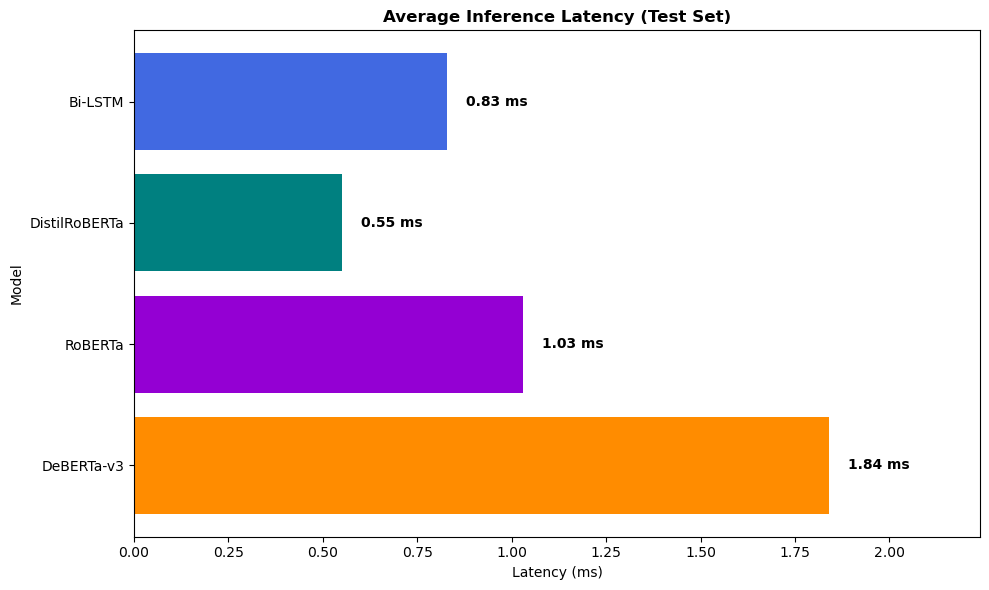

In [49]:
# 6. Visualization - Latency vs Accuracy Comparison (Test Set Only)
fig, ax = plt.subplots(figsize=(10, 6))

bases = [r['Model'] for r in test_rows]
latencies = [float(r['Latency (ms)']) for r in test_rows]
colors_list = [colors.get(b, 'gray') for b in bases]

bars = ax.barh(bases, latencies, color=colors_list)
ax.invert_yaxis()

for bar, v in zip(bars, latencies):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.2f} ms', va='center', fontweight='bold')

ax.set_xlim(0, max(latencies) + 0.4)
ax.set_title('Average Inference Latency (Test Set)', fontweight='bold')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'latency_test.png'), bbox_inches='tight')
plt.show()



## Save Predictor Wrapper for Deployment
This defines a unified class wrapper `MultiTaskPredictor` that simplifies prediction for any of our models, yielding both Fake/Real and AI/Human classifications.


In [50]:
class MultiTaskPredictor:
    def __init__(self, model_type, model_path, tokenizer_path=None, vocab_path=None, cfg=None, device='cpu'):
        self.model_type = model_type
        self.cfg = cfg
        self.device = torch.device(device)
        
        if model_type == 'bilstm':
            self.vocab = joblib.load(vocab_path)
            self.model = BiLSTMMTLClassifier(len(self.vocab), 300, 256)
            sd = torch.load(model_path, map_location=self.device)
            msd = {k.replace("veracity_head", "fake_real_head").replace("origin_head", "ai_human_head"): v for k, v in sd.items()}
            self.model.load_state_dict(msd)
            self.model = self.model.eval().to(self.device)
            self.tokenizer = None
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
            backbone = 'distilroberta-base' if model_type == 'distilroberta' else (
                'roberta-base' if model_type == 'roberta' else 'microsoft/deberta-v3-base'
            )
            self.model = TransformerMTLClassifier(backbone)
            sd = torch.load(model_path, map_location=self.device)
            msd = {k.replace("veracity_head", "fake_real_head").replace("origin_head", "ai_human_head"): v for k, v in sd.items()}
            self.model.load_state_dict(msd)
            self.model = self.model.eval().to(self.device)
            
    def _encode_bilstm(self, title, text):
        combined = clean(title, lower=True) + ' ' + clean(text, lower=True)
        ids = [self.vocab.get(w, 1) for w in combined.split()[:300]]
        ids += [0] * (300 - len(ids))
        return torch.tensor([ids], dtype=torch.long).to(self.device)
        
    def _encode_transformer(self, title, text):
        enc = self.tokenizer(
            clean(title, lower=False),
            clean(text, lower=False),
            max_length=256,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {k: v.to(self.device) for k, v in enc.items()}
        
    @torch.no_grad()
    def predict(self, title: str, text: str) -> dict:
        if self.model_type == 'bilstm':
            x = self._encode_bilstm(title, text)
            logits_fake_real, logits_ai_human = self.model(x)
        else:
            x = self._encode_transformer(title, text)
            logits_fake_real, logits_ai_human = self.model(**x)
            
        probs_fake_real = torch.softmax(logits_fake_real, dim=1)[0].cpu().numpy()
        probs_ai_human = torch.softmax(logits_ai_human, dim=1)[0].cpu().numpy()
        
        return {
            'fake_real': {
                'label': 'Real' if probs_fake_real[0] >= 0.5 else 'Fake',
                'fake_probability': float(probs_fake_real[1]),
                'real_probability': float(probs_fake_real[0])
            },
            'ai_human': {
                'label': 'AI Generated' if probs_ai_human[1] >= 0.5 else 'Human',
                'human_probability': float(probs_ai_human[0]),
                'ai_probability': float(probs_ai_human[1])
            }
        }

# Save predictor metadata
predictor_meta = {
    'available_models': list(results.keys()),
    'configs': {
        'bilstm': {'vocab_size': 50000, 'embed_dim': 300, 'hidden_dim': 256, 'max_len': 300},
        'distilroberta': {'model_name': 'distilroberta-base', 'max_len': 256},
        'roberta': {'model_name': 'roberta-base', 'max_len': 256},
        'deberta': {'model_name': 'microsoft/deberta-v3-base', 'max_len': 256}
    }
}
joblib.dump(predictor_meta, os.path.join(SAVE_DIR, 'predictor_meta.pkl'))
print('Predictor metadata saved successfully.')


Predictor metadata saved successfully.
